# Notebook 07 - Attention Analysis & Model Interpretability

## Environment Setup and Configuration

Initialises the analysis environment by importing core libraries for data handling, model loading, and visualisation. The system path is configured to enable access to project-level modules, including shared configuration parameters.

Global plotting styles and colour palettes are defined to ensure consistency across all generated figures. Additionally, a dedicated directory for attention analysis outputs is created, supporting organised storage of visualisations produced in subsequent sections.

In [1]:
# System Path Configuration
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np
import pickle

# PyTorch and Transformer Components
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Visualisation and Warning Management
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Auto-Detect Best Checkpoint Inside PUBMEDBERT_DIR
import glob, json as _json

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    PUBMEDBERT_MODEL_ID,
    PUBMEDBERT_DIR,
    PUBMEDBERT_PREDS_PKL,
    PLOTS_DIR,
    MAX_LENGTH,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
)

# Attention Analysis Output Directory Setup
ATTENTION_DIR = PLOTS_DIR / "attention_analysis"
ATTENTION_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Settings
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

d:\Lancaster University Coursework\Term 2\SCC 453 - Natural Language Processing and Language Models\Coursework Code\using mimic data\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Loading and Test Set Reconstruction

Initialises the computation device and loads the PubMedBERT tokenizer and fine-tuned model checkpoint with attention outputs enabled. The best available checkpoint is automatically selected using the training metadata where possible, with fallback strategies ensuring robustness when metadata is unavailable.

The test dataset is then reconstructed using the same stratified splitting procedure as earlier stages of the pipeline, ensuring consistency with prior evaluations. Finally, previously saved model predictions are loaded to enable direct comparison and downstream attention-based analysis.

In [2]:
# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

# Load PubMedBERT Tokeniser
tokenizer = AutoTokenizer.from_pretrained(PUBMEDBERT_MODEL_ID)
pubmedbert_path = PUBMEDBERT_DIR

# Attempt to locate best checkpoint from trainer_state.json
trainer_state_path = os.path.join(pubmedbert_path, 'trainer_state.json')
if os.path.exists(trainer_state_path):
    with open(trainer_state_path) as _f:
        state = _json.load(_f)

    best_ckpt = state.get('best_model_checkpoint', None)

    # Use recorded best checkpoint if valid
    if best_ckpt and os.path.exists(best_ckpt):
        pubmedbert_path = best_ckpt
        print(f'Best checkpoint (from trainer_state.json): {best_ckpt}')
    else:
        # Fallback: select latest checkpoint based on step number
        ckpt_dirs = sorted(glob.glob(os.path.join(PUBMEDBERT_DIR, 'checkpoint-*')))
        valid = [d for d in ckpt_dirs if os.path.exists(os.path.join(d, 'config.json'))]

        if valid:
            pubmedbert_path = valid[-1]
            print(f'Best checkpoint (last saved): {pubmedbert_path}')

else:
    # No trainer state available — scan for checkpoint subdirectories
    ckpt_dirs = sorted(glob.glob(os.path.join(PUBMEDBERT_DIR, 'checkpoint-*')))
    valid = [d for d in ckpt_dirs if os.path.exists(os.path.join(d, 'config.json'))]

    if valid:
        pubmedbert_path = valid[-1]
    else:
        print(f'Using directory as-is: {pubmedbert_path}')

# Load PubMedBERT Model With Attention Outputs Enabled
model = AutoModelForSequenceClassification.from_pretrained(
    pubmedbert_path,
    output_attentions=True,
    ignore_mismatched_sizes=True,
)

model.to(device)
model.eval()

# Reconstruct Test Set (Consistent with Previous Notebook Splits)
df = pd.read_csv(LABELLED_DATASET)

X = df['narrative'].to_numpy(dtype=str)
y = df['readmission_30d'].to_numpy(dtype=int)

# Initial train/test split
_, X_temp, _, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Load Saved Predictions
with open(PUBMEDBERT_PREDS_PKL, 'rb') as f:
    pm_preds = pickle.load(f)

y_pred = pm_preds['y_pred']
y_prob = pm_preds['y_prob']

# Summary Output
print(f'Test set : {len(X_test):,} samples')
print(f'Test ROC-AUC (saved) : {pm_preds["roc_auc"]:.4f}')

Device : cuda


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1004.69it/s, Materializing param=classifier.weight]                                     


Test set : 3,610 samples
Test ROC-AUC (saved) : 0.7113


## Attention Extraction and Token Processing Utilities

Defines helper functions for extracting token-level attention weights from the fine-tuned PubMedBERT model and converting subword token outputs into interpretable whole-word representations. The extracted attention values are averaged across layers and heads to obtain a single aggregate attention score per token.

A token filtering scheme is also introduced to remove punctuation, structural tokens, and low-information words that do not contribute meaningful clinical interpretation. This improves the clarity of downstream visualisations by emphasising medically relevant terms within each narrative.

In [3]:
# Attention Extraction Function
def get_attention_weights(text, model, tokenizer, max_length=MAX_LENGTH, device=device):
    # Tokenise and encode input text
    enc = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    # Run model inference without gradient tracking
    with torch.no_grad():
        outputs = model(**enc)

    # Stack attention outputs across layers
    attn_layers = torch.stack(outputs.attentions)
    attn_layers = attn_layers.squeeze(1)

    # Average attention across layers and heads
    attn_mean = attn_layers.mean(dim=0)
    attn_mean = attn_mean.mean(dim=0)

    # Compute received attention per token
    attn_recv = attn_mean.mean(dim=0).cpu().numpy()

    # Mask out padding tokens
    mask = enc['attention_mask'][0].cpu().numpy()
    attn_recv = attn_recv * mask

    # Convert input IDs back to tokens
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0].cpu().numpy())

    return tokens, attn_recv, outputs.logits[0].cpu().numpy()


# Tokens to Filter
SKIP_TOKENS = {
    '.', ',', '(', ')', ':', ';', '-', '/', '!', '?', "'", '"',
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'and', 'or', 'the', 'a', 'an', 'is', 'are', 'was', 'has', 'have',
    'no', 'not', 'per', 'with', 'for', 'of', 'in', 'at', 'to', 'this',
    'that', 'be', 'by', 'as', 'it', 'its', 'was', 'were', 'been', 'unitsml', 'syringe',
}


# Subword-to-Word Reconstruction Function
def tokens_to_words(tokens, attn):
    words = []
    word_attn = []
    cur_word = ''
    cur_attn = 0.0

    for tok, a in zip(tokens, attn):
        # Skip special tokens and finalise current word if needed
        if tok in ('[CLS]', '[SEP]', '[PAD]', '<s>', '</s>'):
            if cur_word:
                words.append(cur_word)
                word_attn.append(cur_attn)
                cur_word = ''
                cur_attn = 0.0
            continue

        # Append continuation subwords to the current token
        if tok.startswith('##'):
            cur_word += tok[2:]
            cur_attn += float(a)
        else:
            # Save completed word before starting a new one
            if cur_word:
                words.append(cur_word)
                word_attn.append(cur_attn)
            cur_word = tok
            cur_attn = float(a)

    # Append final word if present
    if cur_word:
        words.append(cur_word)
        word_attn.append(cur_attn)

    # Lowercase and filter non-informative tokens
    filtered_words = []
    filtered_attn = []

    for w, a in zip(words, word_attn):
        w_lower = w.lower().strip()
        if (
            w_lower not in SKIP_TOKENS
            and len(w_lower) >= 3
            and not w_lower.isdigit()
            and not all(c in '.,;:()-/' for c in w_lower)
        ):
            filtered_words.append(w_lower)
            filtered_attn.append(a)

    return filtered_words, np.array(filtered_attn)


# Summary Output
print(f'Skip token filter: {len(SKIP_TOKENS)} tokens')

Skip token filter: 52 tokens


## Representative Attention Profiles by Prediction Outcome

Selects one representative test sample from each prediction outcome category: true positive, true negative, false negative, and false positive. For each group, the highest-confidence example is chosen to provide a clear and interpretable illustration of the model’s attention behaviour under different classification scenarios.

Attention weights are extracted and aggregated at the word level, then visualised for the top twenty most attended terms in each narrative. Clinically relevant keywords are highlighted separately to support qualitative inspection of whether the model is attending to medically meaningful signals when making correct and incorrect predictions.

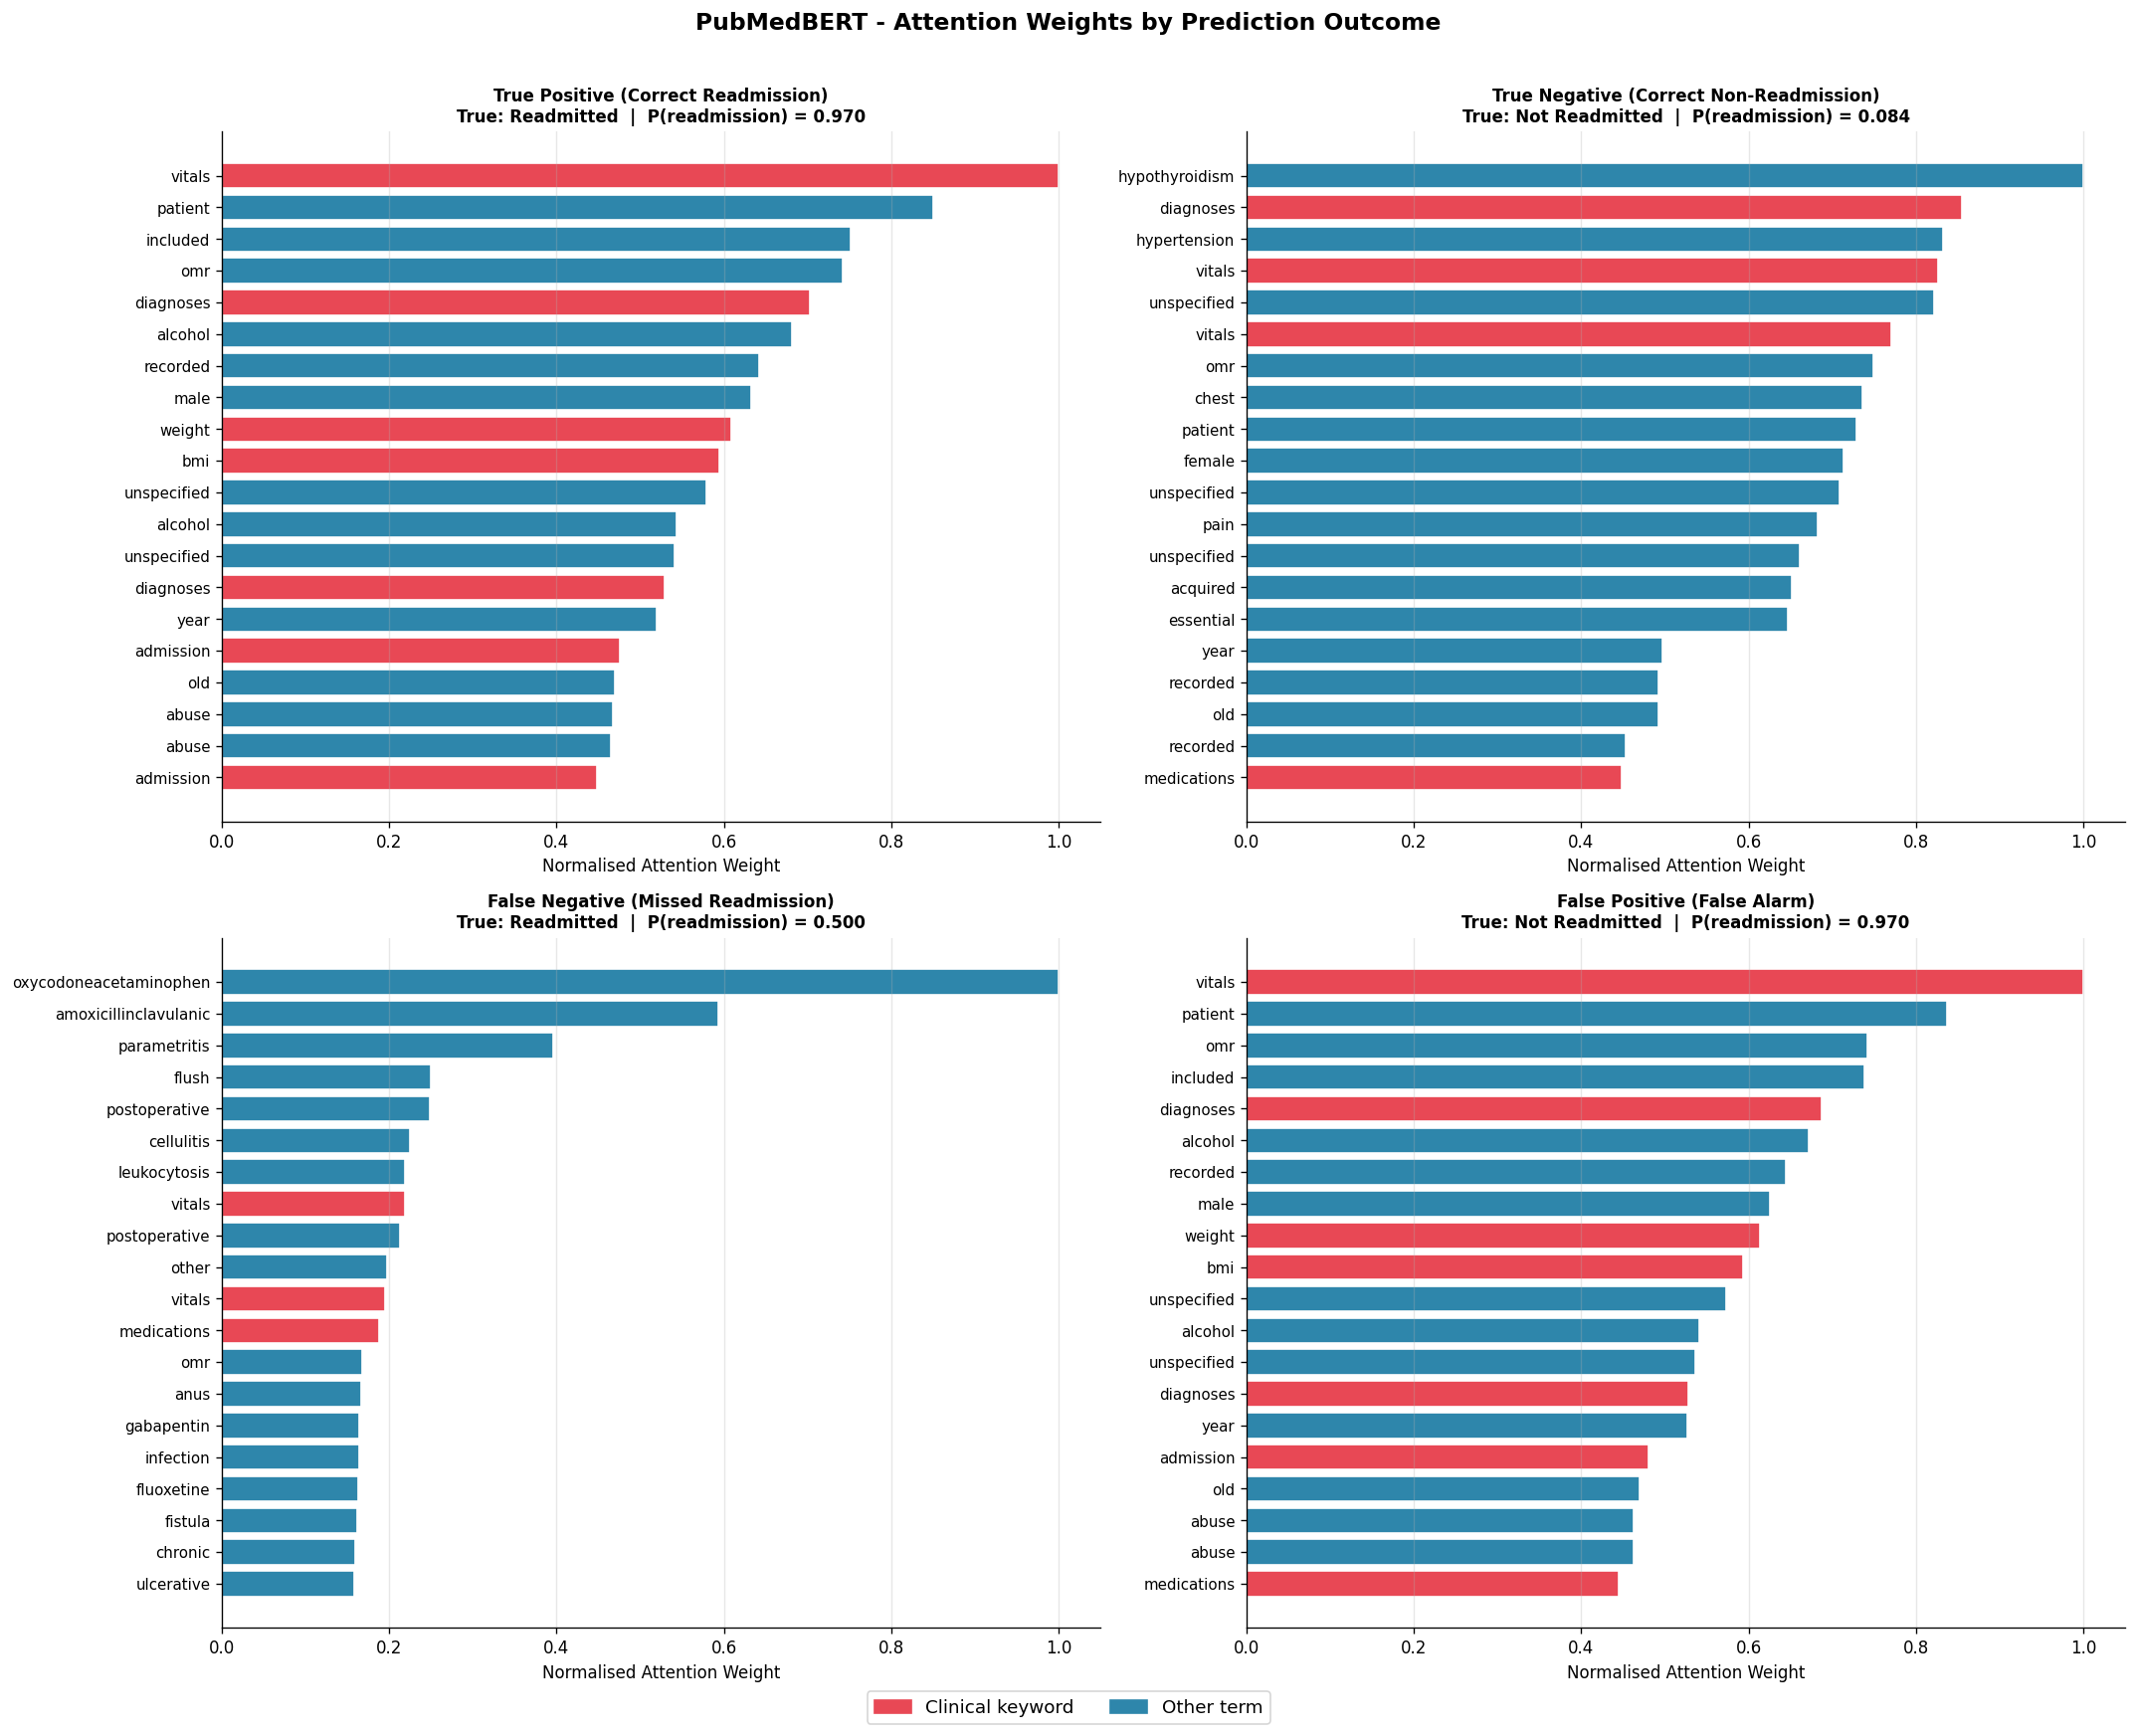

In [4]:
# Select Representative Samples by Prediction Outcome
tp_idx = np.where((y_pred == 1) & (y_test == 1))[0]
tn_idx = np.where((y_pred == 0) & (y_test == 0))[0]
fn_idx = np.where((y_pred == 0) & (y_test == 1))[0]
fp_idx = np.where((y_pred == 1) & (y_test == 0))[0]

# Select Highest-Confidence Sample from Each Outcome Group
samples = {
    'True Positive (Correct Readmission)': tp_idx[np.argmax(y_prob[tp_idx])],
    'True Negative (Correct Non-Readmission)': tn_idx[np.argmin(y_prob[tn_idx])],
    'False Negative (Missed Readmission)': fn_idx[np.argmax(y_prob[fn_idx])],
    'False Positive (False Alarm)': fp_idx[np.argmax(y_prob[fp_idx])],
}

# Create Multi-Panel Figure
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (title, idx) in zip(axes, samples.items()):
    text = X_test[idx]
    label = y_test[idx]
    prob = y_prob[idx]

    # Extract token-level attention and reconstruct whole-word attention
    tokens, attn, logit = get_attention_weights(text, model, tokenizer)
    words, word_attn = tokens_to_words(tokens, attn)

    # Normalise attention weights for comparability within each sample
    if word_attn.max() > 0:
        word_attn = word_attn / word_attn.max()

    # Select top 20 most attended words
    top_idx = np.argsort(word_attn)[-20:]
    top_words = [words[i] for i in top_idx]
    top_attn = word_attn[top_idx]

    # Highlight clinically meaningful keywords
    clinical_keywords = {
        'prior', 'admission', 'readmission', 'diagnoses', 'medications',
        'laboratory', 'abnormal', 'icu', 'admitted', 'history',
        'bmi', 'weight', 'vitals', 'days', 'labs'
    }
    bar_colors = [
        PALETTE[1] if w.lower() in clinical_keywords else PALETTE[0]
        for w in top_words
    ]

    # Plot horizontal attention bar chart
    ax.barh(range(len(top_words)), top_attn, color=bar_colors, edgecolor='white')
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words, fontsize=9)
    ax.set_xlabel('Normalised Attention Weight')

    label_str = 'Readmitted' if label == 1 else 'Not Readmitted'
    ax.set_title(
        f'{title}\nTrue: {label_str}  |  P(readmission) = {prob:.3f}',
        fontweight='bold',
        fontsize=10
    )
    ax.grid(True, axis='x', alpha=0.3)

# Add Figure-Level Legend
import matplotlib.patches as mpatches

legend_elements = [
    mpatches.Patch(color=PALETTE[1], label='Clinical keyword'),
    mpatches.Patch(color=PALETTE[0], label='Other term'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02)
)

# Add Overall Title and Save Figure
plt.suptitle(
    'PubMedBERT - Attention Weights by Prediction Outcome',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_01_sample_attention.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Aggregate Attention Patterns Across Test Samples

Aggregates word-level attention across a random subset of test narratives to identify terms that consistently receive high attention during model prediction. The analysis is stratified by predicted class, allowing comparison between words emphasised when the model predicts readmission versus non-readmission.

To improve robustness, attention weights are normalised within each sample before aggregation, and mean attention is computed only for words occurring a minimum number of times. This reduces the influence of rare terms and highlights more stable attention patterns across the test set.

In [5]:
# Aggregate Attention Across Test Samples
SAMPLE_N = min(300, len(X_test))
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test), size=SAMPLE_N, replace=False)

print(f'Extracting attention from {SAMPLE_N} test samples...')

word_attn_pos = {}
word_attn_neg = {}
word_count = {}

for i, idx in enumerate(sample_idx):
    # Report progress periodically during extraction
    if i % 75 == 0:
        print(f'  Progress: {i}/{SAMPLE_N}')

    tokens, attn, _ = get_attention_weights(X_test[idx], model, tokenizer)
    words, word_attn = tokens_to_words(tokens, attn)

    # Normalise attention within each sample
    if word_attn.max() > 0:
        word_attn = word_attn / word_attn.max()

    # Group attention by predicted class
    target = word_attn_pos if y_pred[idx] == 1 else word_attn_neg

    for w, a in zip(words, word_attn):
        # tokens_to_words already applies lowercasing and filtering
        target[w] = target.get(w, 0.0) + float(a)
        word_count[w] = word_count.get(w, 0) + 1

print(f'Unique words seen: {len(word_count):,}')


# Helper Function for Ranking Words by Mean Attention
def top_words_by_attention(attn_dict, n=25, min_count=5):
    normalised = {
        w: v / word_count[w]
        for w, v in attn_dict.items()
        if word_count.get(w, 0) >= min_count
    }
    return sorted(normalised.items(), key=lambda x: x[1], reverse=True)[:n]


# Extract Most Attended Words for Each Predicted Class
top_pos = top_words_by_attention(word_attn_pos)
top_neg = top_words_by_attention(word_attn_neg)

# Summary Output
print(f'\nTop 12 attended words when predicting READMITTED:')
for w, a in top_pos[:12]:
    print(f'  {w:<30} {a:.4f}')

print(f'\nTop 12 attended words when predicting NOT READMITTED:')
for w, a in top_neg[:12]:
    print(f'  {w:<30} {a:.4f}')

Extracting attention from 300 test samples...
  Progress: 0/300
  Progress: 75/300
  Progress: 150/300
  Progress: 225/300
Unique words seen: 1,724

Top 12 attended words when predicting READMITTED:
  acyclovir                      0.6299
  torsemide                      0.6146
  piccmidline                    0.6000
  pancytopenia                   0.5767
  diverticulitis                 0.5722
  lactulose                      0.5576
  antineoplastic                 0.5025
  piperacillintazobactam         0.5000
  hyposmolality                  0.4938
  varices                        0.4889
  septicemia                     0.4776
  ascites                        0.4628

Top 12 attended words when predicting NOT READMITTED:
  nonrheumatic                   0.8817
  oxycodoneacetaminophen         0.8223
  ipratropium                    0.7903
  postprocedural                 0.7685
  migrainosus                    0.7046
  hemiplegia                     0.6875
  cholecystitis           

## Top Attended Words by Predicted Class

Visualises the most highly attended words associated with each predicted class using aggregated attention scores across the sampled test set. Separate panels are used for readmission and non-readmission predictions, enabling direct comparison of the lexical features emphasised by the model under each decision outcome.

By displaying the highest-ranked terms according to mean normalised attention, this plot supports qualitative assessment of whether the model is prioritising clinically plausible concepts when distinguishing between the two classes.

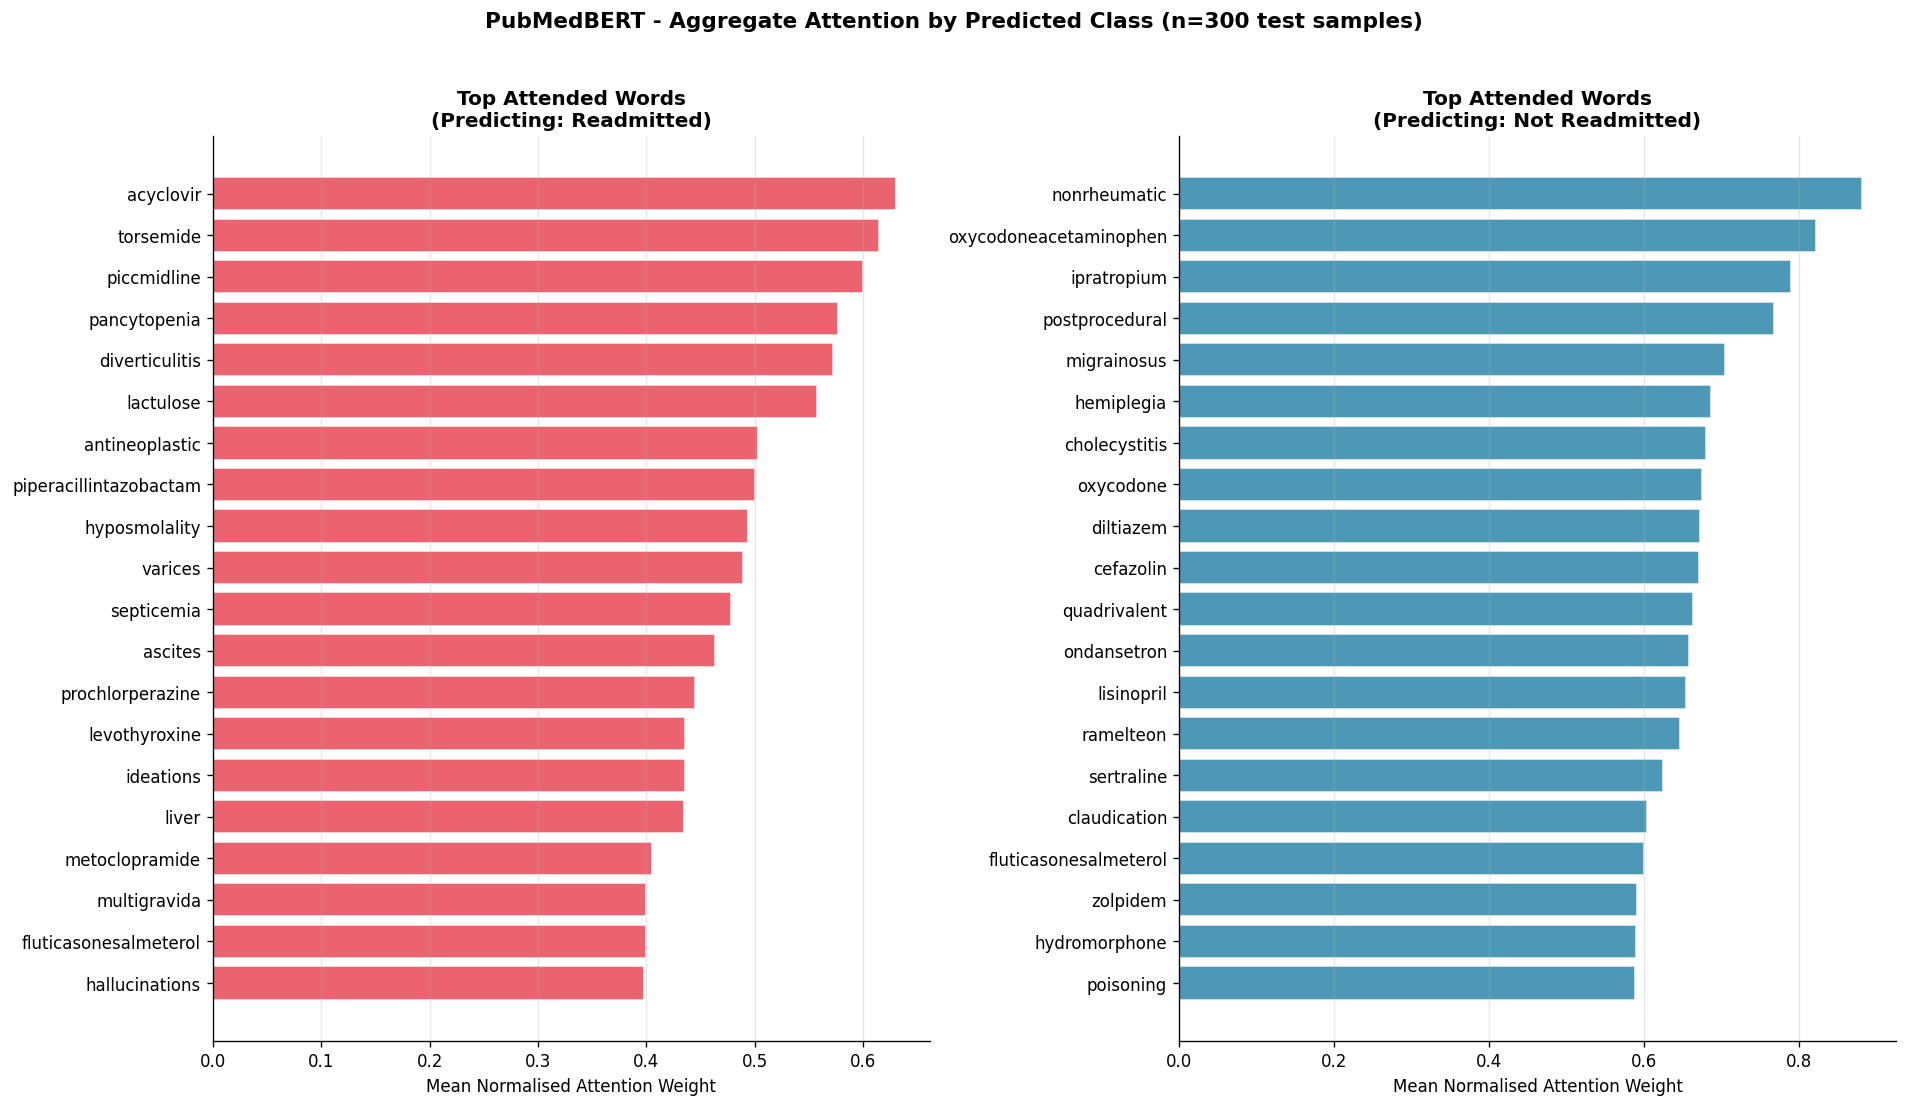

In [6]:
# Plot Top Attended Words by Predicted Class
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, top_items, title, color in [
    (axes[0], top_pos, 'Top Attended Words\n(Predicting: Readmitted)', PALETTE[1]),
    (axes[1], top_neg, 'Top Attended Words\n(Predicting: Not Readmitted)', PALETTE[0]),
]:
    words = [w for w, _ in top_items[:20]]
    scores = [a for _, a in top_items[:20]]

    # Reverse order so the highest-attended term appears at the top
    ax.barh(
        range(len(words)),
        scores[::-1],
        color=color,
        edgecolor='white',
        alpha=0.85
    )
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words[::-1], fontsize=10)
    ax.set_xlabel('Mean Normalised Attention Weight')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(True, axis='x', alpha=0.3)

# Add Overall Title and Save Figure
plt.suptitle(
    'PubMedBERT - Aggregate Attention by Predicted Class (n=300 test samples)',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_02_aggregate_attention_by_class.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Attention Distribution Across Clinical Domains

Groups clinically relevant terms into predefined semantic domains and compares their mean attention weights across the sampled test set. This provides a higher-level view of the types of medical concepts the model tends to prioritise, beyond individual word-level analysis.

To estimate overall importance, attention values from both predicted classes are combined and averaged across occurrences. Visualising attention at the domain level helps assess whether model focus is concentrated on diagnostically meaningful content, treatment-related information, laboratory indicators, temporal history, or critical care terminology.

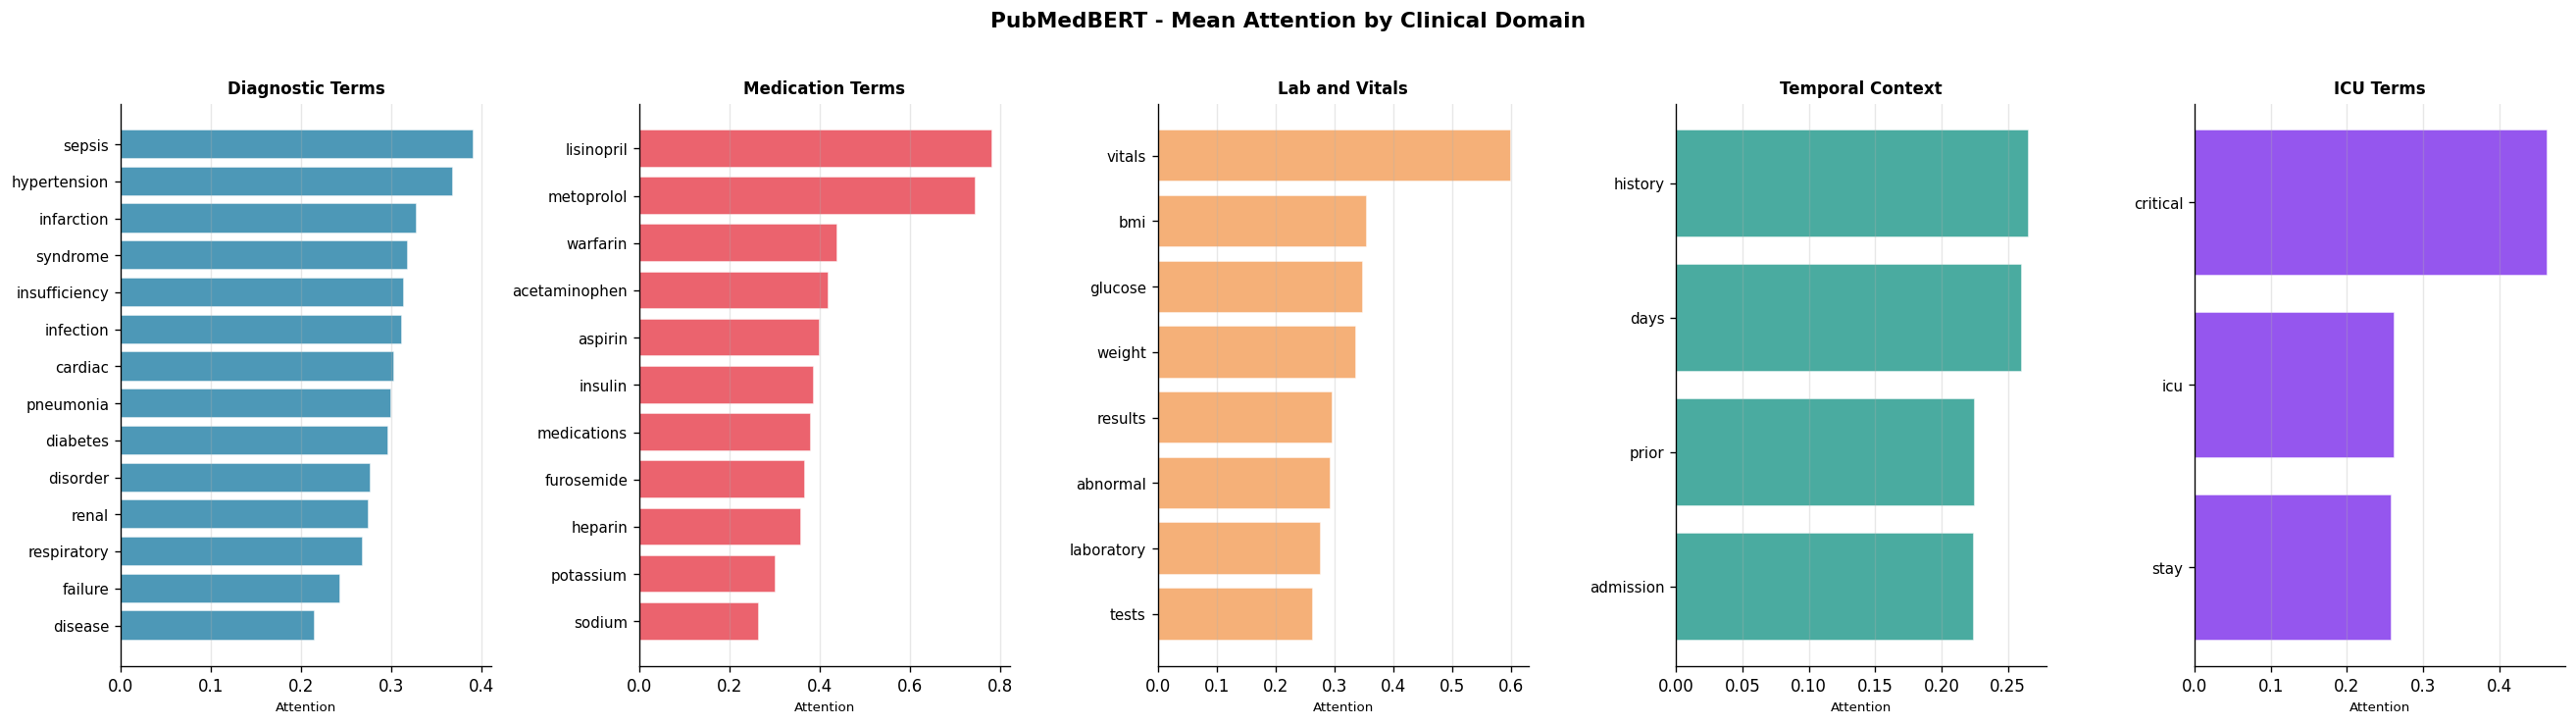

In [7]:
# Clinical Domain Attention Analysis
clinical_domains = {
    'Diagnostic Terms': [
        'infarction', 'hypertension', 'diabetes', 'failure',
        'pneumonia', 'sepsis', 'stroke', 'renal', 'cardiac',
        'respiratory', 'infection', 'disorder', 'disease',
        'insufficiency', 'syndrome'
    ],
    'Medication Terms': [
        'insulin', 'furosemide', 'metoprolol', 'heparin',
        'acetaminophen', 'potassium', 'sodium', 'warfarin',
        'aspirin', 'lisinopril', 'medications', 'medication'
    ],
    'Lab and Vitals': [
        'abnormal', 'laboratory', 'labs', 'bmi', 'weight',
        'tests', 'results', 'percent', 'creatinine',
        'glucose', 'hemoglobin', 'vitals'
    ],
    'Temporal Context': [
        'prior', 'admission', 'previous', 'readmission',
        'days', 'history', 'admissions', 'discharge'
    ],
    'ICU Terms': [
        'icu', 'intensive', 'ventilation', 'critical',
        'monitoring', 'stay'
    ],
}

# Combine Attention Across Predicted Classes
all_attn = {}

for w in set(list(word_attn_pos.keys()) + list(word_attn_neg.keys())):
    total = word_attn_pos.get(w, 0) + word_attn_neg.get(w, 0)
    cnt = word_count.get(w, 1)

    if cnt >= 3:
        all_attn[w] = total / cnt

# Plot Mean Attention by Clinical Domain
n_domains = len(clinical_domains)
fig, axes = plt.subplots(1, n_domains, figsize=(22, 6))

for ax, (domain, terms), color_idx in zip(
    axes, clinical_domains.items(), range(n_domains)
):
    # Extract attention values for terms present in the aggregated vocabulary
    domain_data = [
        (term, all_attn.get(term, 0))
        for term in terms
        if all_attn.get(term, 0) > 0
    ]

    if not domain_data:
        ax.set_visible(False)
        continue

    # Sort in ascending order for horizontal bar plotting
    domain_data.sort(key=lambda x: x[1])
    terms_plot = [d[0] for d in domain_data]
    scores = [d[1] for d in domain_data]

    ax.barh(
        range(len(terms_plot)),
        scores,
        color=PALETTE[color_idx % len(PALETTE)],
        edgecolor='white',
        alpha=0.85
    )
    ax.set_yticks(range(len(terms_plot)))
    ax.set_yticklabels(terms_plot, fontsize=9)
    ax.set_title(domain, fontweight='bold', fontsize=10)
    ax.set_xlabel('Attention', fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)

# Add Overall Title and Save Figure
plt.suptitle(
    'PubMedBERT - Mean Attention by Clinical Domain',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_03_clinical_domain_attention.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Attention Allocation Across Narrative Sections

Examines how attention is distributed across major structural components of each synthetic clinical narrative, including demographics, admission history, diagnoses, medications, laboratory information, vital signs, and ICU status. Rather than focusing on individual words alone, this analysis estimates which sections of the narrative receive greater emphasis during prediction.

Section-level attention is approximated using representative keywords for each narrative component, and mean normalised attention is computed separately for readmission and non-readmission predictions. This provides a more interpretable view of whether the model is relying more heavily on particular parts of the patient summary when forming its classification decision.

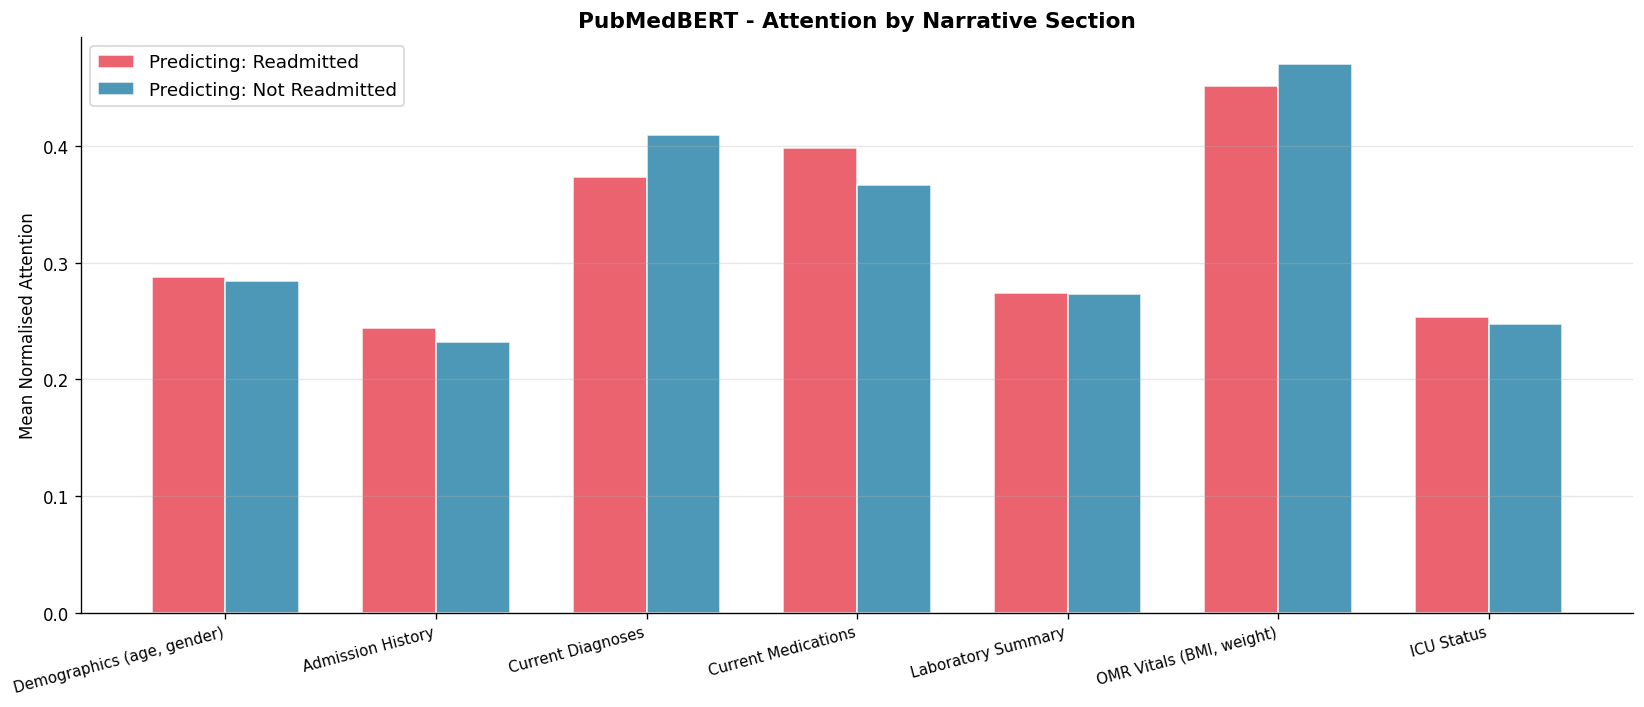

In [8]:
# Section-Level Attention Analysis
section_keywords = {
    'Demographics (age, gender)': ['patient', 'year', 'old', 'male', 'female'],
    'Admission History': ['admission', 'prior', 'admissions', 'previously'],
    'Current Diagnoses': ['diagnoses', 'diagnosis', 'diagnosed'],
    'Current Medications': ['medications', 'medication'],
    'Laboratory Summary': ['laboratory', 'labs', 'abnormal', 'percent', 'tests'],
    'OMR Vitals (BMI, weight)': ['vitals', 'bmi', 'weight'],
    'ICU Status': ['icu', 'intensive', 'stay'],
}

# Compute Mean Attention for Each Section Across All Sampled Test Cases
section_attn_pos = {s: [] for s in section_keywords}
section_attn_neg = {s: [] for s in section_keywords}

for i, idx in enumerate(sample_idx):
    tokens, attn, _ = get_attention_weights(X_test[idx], model, tokenizer)
    words, word_attn = tokens_to_words(tokens, attn)

    # Normalise attention within each sample
    if word_attn.max() > 0:
        word_attn = word_attn / word_attn.max()

    # Convert word-level attention into a lookup dictionary
    word_dict = {w.lower(): float(a) for w, a in zip(words, word_attn)}

    # Separate aggregation by predicted class
    target = section_attn_pos if y_pred[idx] == 1 else section_attn_neg

    # Estimate section attention using representative keywords
    for section, keywords in section_keywords.items():
        section_scores = [word_dict.get(kw, 0) for kw in keywords if kw in word_dict]
        if section_scores:
            target[section].append(np.mean(section_scores))

# Compute Mean Attention Per Narrative Section
pos_means = {s: np.mean(v) if v else 0 for s, v in section_attn_pos.items()}
neg_means = {s: np.mean(v) if v else 0 for s, v in section_attn_neg.items()}

sections = list(section_keywords.keys())
pos_vals = [pos_means[s] for s in sections]
neg_vals = [neg_means[s] for s in sections]

# Plot Attention by Section and Predicted Class
x = np.arange(len(sections))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    x - w / 2,
    pos_vals,
    w,
    label='Predicting: Readmitted',
    color=PALETTE[1],
    edgecolor='white',
    alpha=0.85
)
ax.bar(
    x + w / 2,
    neg_vals,
    w,
    label='Predicting: Not Readmitted',
    color=PALETTE[0],
    edgecolor='white',
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(sections, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Normalised Attention')
ax.set_title(
    'PubMedBERT - Attention by Narrative Section',
    fontweight='bold',
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Save and Display Figure
plt.tight_layout()
plt.savefig(
    f'{ATTENTION_DIR}/att_04_section_attention.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Interpretability Summary Report

Summarises the main findings from the attention analysis by reporting the highest-attended terms for each predicted class and providing a brief qualitative interpretation of the observed patterns. This final section is intended to consolidate the main interpretability insights into a concise, report-ready output.

The summary links the attention distributions back to clinically meaningful narrative components, including temporal history, laboratory abnormalities, vital sign information, and utilisation-related indicators. This supports a more coherent interpretation of how the model appears to prioritise information when estimating readmission risk.

In [9]:
# Interpretability Summary Report
print('Attention Analysis Summary')
print('-' * 65)

print('\nTop 10 attended terms when predicting READMISSION:')
for rank, (w, a) in enumerate(top_pos[:10], 1):
    print(f'  {rank:>2}. {w:<30} attention = {a:.4f}')

print('\nTop 10 attended terms when predicting NO READMISSION:')
for rank, (w, a) in enumerate(top_neg[:10], 1):
    print(f'  {rank:>2}. {w:<30} attention = {a:.4f}')

Attention Analysis Summary
-----------------------------------------------------------------

Top 10 attended terms when predicting READMISSION:
   1. acyclovir                      attention = 0.6299
   2. torsemide                      attention = 0.6146
   3. piccmidline                    attention = 0.6000
   4. pancytopenia                   attention = 0.5767
   5. diverticulitis                 attention = 0.5722
   6. lactulose                      attention = 0.5576
   7. antineoplastic                 attention = 0.5025
   8. piperacillintazobactam         attention = 0.5000
   9. hyposmolality                  attention = 0.4938
  10. varices                        attention = 0.4889

Top 10 attended terms when predicting NO READMISSION:
   1. nonrheumatic                   attention = 0.8817
   2. oxycodoneacetaminophen         attention = 0.8223
   3. ipratropium                    attention = 0.7903
   4. postprocedural                 attention = 0.7685
   5. migrainosu